<a href="https://colab.research.google.com/github/arya2005-tech/CSL701-CS44-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>





Student Name :Arya Abhiram Prabhudesai

Batch :CS-3


Roll Number :CS44



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Breast Cancer Wisconsin Diagnostic dataset
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Add target column
df["diagnosis"] = data.target

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Shape:
(569, 31)

Column Names:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'diagnosis'],
      dtype='object')

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points  

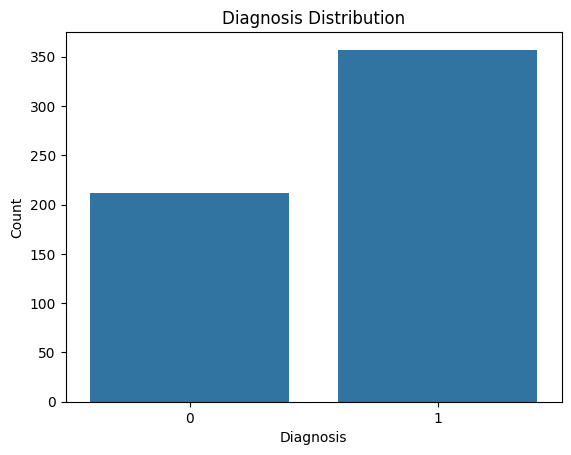

In [7]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [9]:
# Check and remove unnecessary columns if they exist
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Separate features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Classes:")
print(y.value_counts())

print("\nFeatures:")
print(X.columns)

Feature Shape: (569, 30)
Target Shape: (569,)

Target Classes:
diagnosis
1    357
0    212
Name: count, dtype: int64

Features:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [10]:
# Standardize the 30 features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed successfully!")
print("Scaled Data Shape:", X_scaled.shape)

print("\nMean of scaled data:", np.mean(X_scaled))
print("Standard deviation of scaled data:", np.std(X_scaled))

Standardization completed successfully!
Scaled Data Shape: (569, 30)

Mean of scaled data: -6.118909323768877e-16
Standard deviation of scaled data: 1.0


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [11]:
# Apply PCA and reduce 30 dimensions to 2
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")
print("Original Shape:", X_scaled.shape)
print("PCA Shape:", X_pca.shape)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Diagnosis"] = y

pca_df.head()

PCA completed successfully!
Original Shape: (569, 30)
PCA Shape: (569, 2)


,PC1,PC2,Diagnosis
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [12]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Variance explained by PC1:", explained_variance[0])
print("Variance explained by PC2:", explained_variance[1])

print("\nPercentage variance explained:")
print("PC1:", explained_variance[0] * 100, "%")
print("PC2:", explained_variance[1] * 100, "%")

# Cumulative variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative variance retained:")
print(cumulative_variance[1] * 100, "%")

Variance explained by PC1: 0.44272025607526366
Variance explained by PC2: 0.1897118204403308

Percentage variance explained:
PC1: 44.272025607526366 %
PC2: 18.971182044033082 %

Cumulative variance retained:
63.243207651559445 %


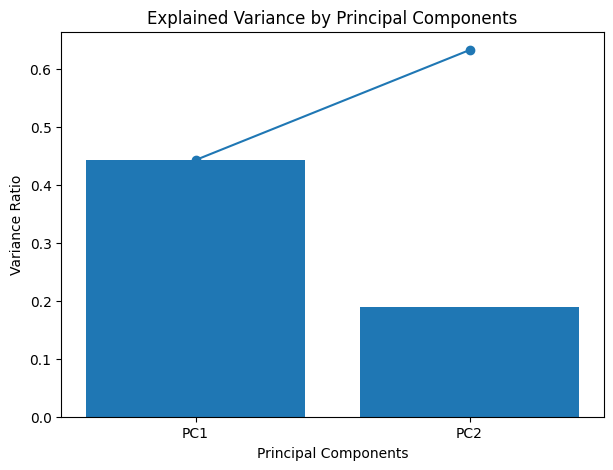

In [13]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance
)

plt.plot(
    ["PC1", "PC2"],
    cumulative_variance,
    marker="o"
)

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")

plt.show()

# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

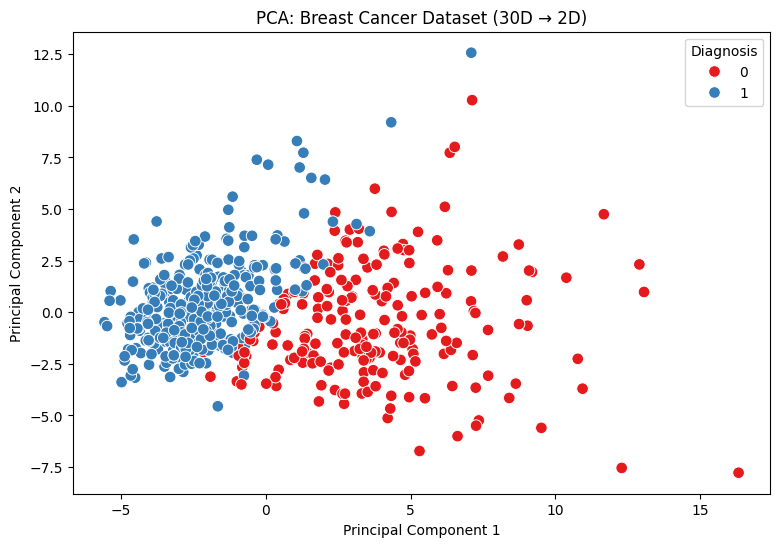

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    data=pca_df,
    palette="Set1",
    s=70
)

plt.title("PCA: Breast Cancer Dataset (30D → 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Diagnosis")

plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [15]:
# Split original scaled dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
lr_raw = LogisticRegression(max_iter=1000)

# Train model
lr_raw.fit(X_train, y_train)

# Prediction
y_pred_raw = lr_raw.predict(X_test)

# Accuracy
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print("Logistic Regression using 30 Features")
print("---------------------------------------")
print("Accuracy:", accuracy_raw)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_raw))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_raw,
    target_names=["Malignant", "Benign"]
))

Logistic Regression using 30 Features
---------------------------------------
Accuracy: 0.9824561403508771

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [16]:
# Split PCA transformed data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
lr_pca = LogisticRegression(max_iter=1000)

# Train model
lr_pca.fit(X_train_pca, y_train_pca)

# Prediction
y_pred_pca = lr_pca.predict(X_test_pca)

# Accuracy
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print("Logistic Regression using 2 PCA Features")
print("-----------------------------------------")
print("Accuracy:", accuracy_pca)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

print("\nClassification Report:")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Malignant", "Benign"]
))

Logistic Regression using 2 PCA Features
-----------------------------------------
Accuracy: 0.9473684210526315

Confusion Matrix:
[[40  2]
 [ 4 68]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.91      0.95      0.93        42
      Benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [17]:
print("============================================")
print("       MODEL PERFORMANCE COMPARISON")
print("============================================")

print("\nAccuracy using 30 Original Features:",
      accuracy_raw)

print("Accuracy using 2 PCA Features:",
      accuracy_pca)

print("\nAccuracy Difference:",
      accuracy_raw - accuracy_pca)

# Comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 30 Features",
        "Logistic Regression - 2 PCA Features"
    ],
    "Number of Features": [
        30,
        2
    ],
    "Accuracy": [
        accuracy_raw,
        accuracy_pca
    ]
})

print("\nComparison Table:")
display(comparison)

       MODEL PERFORMANCE COMPARISON

Accuracy using 30 Original Features: 0.9824561403508771
Accuracy using 2 PCA Features: 0.9473684210526315

Accuracy Difference: 0.03508771929824561

Comparison Table:


,Model,Number of Features,Accuracy
0,Logistic Regression - 30 Features,30,0.982456
1,Logistic Regression - 2 PCA Features,2,0.947368


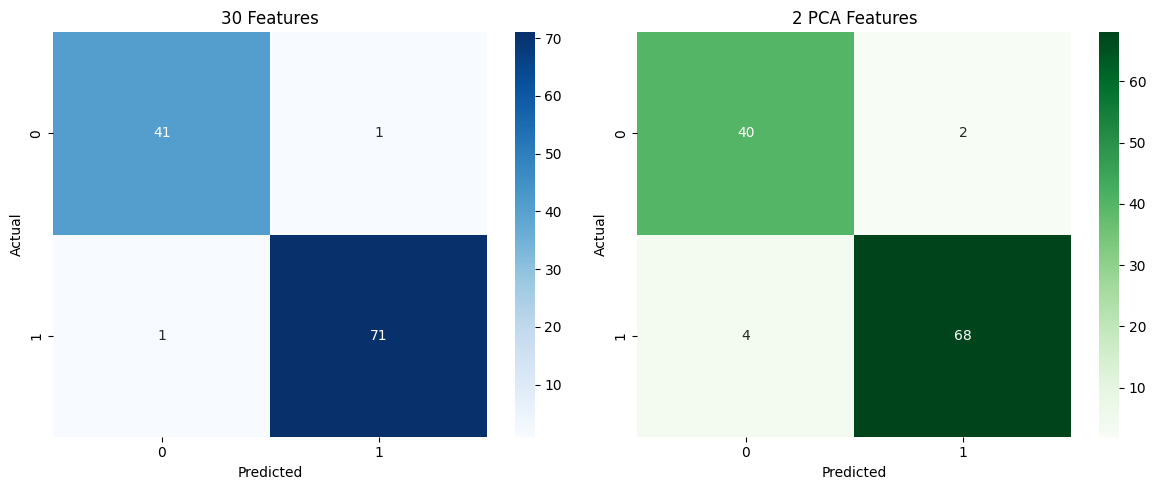

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw features
sns.heatmap(
    confusion_matrix(y_test, y_pred_raw),
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("30 Features")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# PCA features
sns.heatmap(
    confusion_matrix(y_test_pca, y_pred_pca),
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("2 PCA Features")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [19]:
print("Classification Report - Original 30 Features")
print("==============================================")
print(classification_report(
    y_test,
    y_pred_raw,
    target_names=["Malignant", "Benign"]
))

print("\nClassification Report - PCA 2 Features")
print("========================================")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    target_names=["Malignant", "Benign"]
))

Classification Report - Original 30 Features
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Classification Report - PCA 2 Features
              precision    recall  f1-score   support

   Malignant       0.91      0.95      0.93        42
      Benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.